### 불량 탐지 분류 실습

- wafer 이미지 처리: Dataset.zip  압축 해제

In [1]:
import numpy as np
from PIL import Image
import os, glob, random

max_photo = 150
photo_size=32

In [2]:
import os
import glob
import random
dirs = os.listdir("Dataset")

In [3]:
def img_read(dir):
  files = glob.glob( "Dataset/"+dir+"/*.jpg")
  #random.shuffle(files)
  num=0
  tmp1 = []
  tmp2 = []
  print(len(files), dir, num)
  for f in files:
    print(f)
    if num >= max_photo: break
    num +=1
    img = Image.open(f)
    img= img.convert("RGB")
    img= img.resize((photo_size, photo_size))
    img= np.asarray(img)
    tmp1.append(img)
    tmp2.append(dir)	#label을 0으로 지정
  return tmp1, tmp2

In [4]:
x=[]
y=[]

for dir in dirs:
  print(dir)
  x1, y1 = img_read(dir)
  x.append(x1)
  y.append(y1)

Center
100 Center 0
Dataset/Center\641447.jpg
Dataset/Center\642989.jpg
Dataset/Center\646177.jpg
Dataset/Center\648236.jpg
Dataset/Center\651816.jpg
Dataset/Center\655870.jpg
Dataset/Center\659673.jpg
Dataset/Center\678673.jpg
Dataset/Center\679609.jpg
Dataset/Center\680688.jpg
Dataset/Center\682743.jpg
Dataset/Center\683806.jpg
Dataset/Center\686597.jpg
Dataset/Center\687416.jpg
Dataset/Center\691371.jpg
Dataset/Center\692645.jpg
Dataset/Center\696055.jpg
Dataset/Center\712477.jpg
Dataset/Center\713551.jpg
Dataset/Center\720828.jpg
Dataset/Center\723088.jpg
Dataset/Center\724684.jpg
Dataset/Center\727923.jpg
Dataset/Center\732235.jpg
Dataset/Center\740416.jpg
Dataset/Center\755691.jpg
Dataset/Center\757377.jpg
Dataset/Center\758049.jpg
Dataset/Center\759637.jpg
Dataset/Center\760560.jpg
Dataset/Center\760845.jpg
Dataset/Center\761305.jpg
Dataset/Center\761994.jpg
Dataset/Center\762126.jpg
Dataset/Center\762236.jpg
Dataset/Center\762524.jpg
Dataset/Center\762821.jpg
Dataset/Center\763

In [5]:
x_final = [item for sublist in x for item in sublist]
y_final = [item for sublist in y for item in sublist]

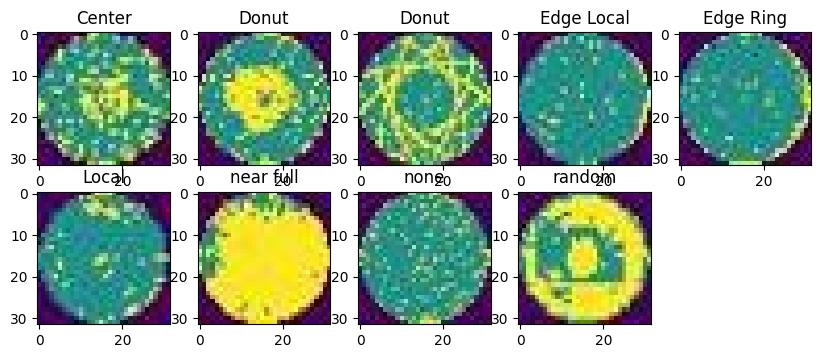

In [6]:
#이미지 출력
import matplotlib.pyplot as plt
idx = 100
plt.figure(figsize=(10,10))
for i in range(9):
 plt.subplot(5,5,i+1)
 plt.title(y_final[i*idx])
 plt.imshow(x_final[i*idx])
plt.show()

#2. 분류 모형 적용

In [7]:
import pandas as pd
X_arr = np.array(x_final).reshape(-1, 32*32*3)
y_arr = np.array(y_final)

X_df = pd.DataFrame(X_arr)
y_df = pd.DataFrame(y_arr)

y_df_ohe = pd.get_dummies(y_df, drop_first=False)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X_df, y_df_ohe, test_size=0.2, random_state=123, stratify=y_df_ohe)

In [9]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [10]:
from sklearn.metrics import classification_report
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.47      0.45      0.46        20
           1       0.42      0.48      0.44        21
           2       0.54      0.62      0.58        21
           3       0.82      0.70      0.76        20
           4       0.47      0.45      0.46        20
           5       0.65      0.75      0.70        20
           6       1.00      0.84      0.91        19
           7       0.89      0.80      0.84        20
           8       0.33      0.35      0.34        20

   micro avg       0.60      0.60      0.60       181
   macro avg       0.62      0.60      0.61       181
weighted avg       0.62      0.60      0.61       181
 samples avg       0.60      0.60      0.60       181



In [11]:
np.argmax( pred, axis=1)

array([6, 2, 1, 1, 0, 8, 0, 0, 0, 1, 7, 2, 7, 4, 4, 1, 4, 8, 5, 2, 6, 2,
       4, 6, 4, 0, 0, 1, 3, 5, 4, 5, 1, 1, 2, 3, 1, 1, 6, 4, 2, 2, 6, 5,
       3, 1, 3, 5, 8, 5, 7, 3, 5, 8, 5, 5, 0, 6, 0, 4, 0, 4, 5, 1, 8, 3,
       1, 3, 7, 8, 4, 8, 0, 5, 5, 8, 7, 2, 7, 1, 6, 0, 2, 3, 2, 7, 0, 5,
       4, 8, 7, 2, 0, 3, 3, 5, 0, 2, 5, 2, 5, 4, 2, 6, 2, 7, 3, 1, 5, 1,
       8, 1, 2, 8, 6, 8, 6, 1, 4, 2, 1, 7, 5, 7, 4, 4, 8, 7, 2, 2, 5, 6,
       1, 8, 7, 3, 4, 7, 1, 2, 4, 0, 4, 2, 5, 6, 1, 3, 8, 1, 0, 8, 3, 3,
       7, 1, 0, 7, 6, 5, 1, 8, 7, 4, 3, 8, 5, 2, 2, 6, 0, 6, 3, 2, 8, 8,
       0, 7, 8, 5, 6])

#### 앙상블 모형 적용

In [ ]:
# Dataset.zip 파일에 대해서 앙상블 모형 4개 적용->좋은 모형 파라미터 탐색
# 900여건 행->train:test = 9:1, train:val = 9:1
# y변수 범주-> 0,1,2,3,4,5,6,7,8 숫자로 변환해서 모델링(OHE 미적용)

In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import label_binarize
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [14]:
class_order = [
    'none',         # 0 (정상)
    'Center',       # 1
    'Donut',        # 2
    'Edge Local',   # 3
    'Edge Ring',    # 4
    'Local',        # 5
    'Scratch',      # 6
    'near full',    # 7
    'random'        # 8
]


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.classes_ = np.array(class_order) #범주 순서 지정
y_encoded = le.fit_transform(y_df)

print(f"원본 클래스 : {le.classes_}")
print(f"인코딩 결과 : {np.unique(y_encoded)}")

# 인코딩 → 원본 복원
y_original = le.inverse_transform(y_encoded)

원본 클래스 : ['Center' 'Donut' 'Edge Local' 'Edge Ring' 'Local' 'Scratch' 'near full'
 'none' 'random']
인코딩 결과 : [0 1 2 3 4 5 6 7 8]


c:\Users\owner\miniconda3\envs\qwer\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# ──────────────────────────────────────────
# 2. Train / Val / Test 분리
# ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (648, 3072), Val: (73, 3072), Test: (181, 3072)


In [16]:
# ──────────────────────────────────────────
# 3. 모델 정의
# ──────────────────────────────────────────
models = {}

# GBM
models['GBM'] = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    n_iter_no_change=50,
    validation_fraction=0.1,
    tol=1e-4,
    random_state=42
)

# LightGBM
models['LightGBM'] = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)

# XGBoost
models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',   # 다중 분류
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)

# CatBoost
models['CatBoost'] = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    eval_metric='Accuracy',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=0
)


In [17]:
# ──────────────────────────────────────────
# 4. 학습 및 평가
# ──────────────────────────────────────────
results = []

for name, model in models.items():
    print(f"\n{name} learning...")

    if name == 'XGBoost':
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
    elif name == 'LightGBM':
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50),
                lgb.log_evaluation(0)
            ]
        )
    elif name == 'CatBoost':
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val)
        )
    else:  # GBM
        model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)          # (N, 9)

    # 다중 분류 ROC-AUC: OvR 방식
    auc = roc_auc_score(
        y_test, y_proba,
        multi_class='ovr',
        average='macro'
    )

    results.append({
        'Model'   : name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC' : auc,
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
    })



GBM learning...

LightGBM learning...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[131]	valid_0's multi_logloss: 0.399269

XGBoost learning...

CatBoost learning...


In [20]:
# ──────────────────────────────────────────
# 5. Isolation Forest (비지도)
# ──────────────────────────────────────────
print("\nIsolationForest")

contamination = float(np.mean(y_train > 0))   # 불량(1~8) 비율을 이상치로 사용
contamination = min(contamination, 0.5)

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples=256,
    random_state=42
)
iso.fit(X_train)

# Isolation Forest는 정상/이상치 이진 판별만 가능
# 불량(y > 0) = 이상치(1), 양품(y == 0) = 정상(0) 으로 변환하여 평가
y_test_binary = (y_test > 0).astype(int)
iso_raw   = iso.predict(X_test)                      # 1(정상), -1(이상치)
iso_pred  = np.where(iso_raw == -1, 1, 0)            # 이상치 → 불량(1)
iso_proba = -iso.score_samples(X_test)               # 높을수록 이상치
iso_proba = (iso_proba - iso_proba.min()) / \
            (iso_proba.max() - iso_proba.min())      # 0~1 정규화

results.append({
    'Model'   : 'IsolationForest',
    'Accuracy': accuracy_score(y_test_binary, iso_pred),
    'ROC-AUC' : roc_auc_score(y_test_binary, iso_proba),
    'F1-macro': f1_score(y_test_binary, iso_pred, average='macro'),
})


IsolationForest


In [21]:
# ──────────────────────────────────────────
# 6. 결과 출력
# ──────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False).round(4)

print("\n" + "=" * 50)
print("         Performance by Models")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)

# 상세 리포트 (best 모델)
best_name = results_df.index[0]
print(f"\nBest Model: {best_name}")

if best_name == 'IsolationForest':
    print(classification_report(y_test_binary, iso_pred,
                                 target_names=['양품(0)', '불량(1~8)']))
else:
    best_pred = models[best_name].predict(X_test)
    print(classification_report(y_test, best_pred,
                                 target_names=[f'class{i}' for i in range(9)]))


         Performance by Models
                 Accuracy  ROC-AUC  F1-macro
Model                                       
LightGBM           0.8177   0.9821    0.8163
XGBoost            0.8011   0.9820    0.7995
CatBoost           0.8343   0.9743    0.8318
GBM                0.7624   0.9622    0.7609
IsolationForest    0.5691   0.7149    0.4797
IsolationForest    0.5691   0.7149    0.4797

Best Model: LightGBM
              precision    recall  f1-score   support

      class0       0.76      0.65      0.70        20
      class1       0.89      0.85      0.87        20
      class2       0.82      0.86      0.84        21
      class3       0.95      0.86      0.90        21
      class4       0.72      0.65      0.68        20
      class5       0.64      0.70      0.67        20
      class6       0.95      1.00      0.97        19
      class7       0.80      1.00      0.89        20
      class8       0.84      0.80      0.82        20

    accuracy                           0.82 